# Deep Learning - Exercise 2

This lecture is about introduction to using ANN for regression tasks.

We will use our models on [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) dataset.

This dataset contains fule consumptions of several vehicles in miles per gallon. So, we need to predict the fuel efficiencies of various vehicles from the data that has been provided.

**Core Concepts**
* ⛽ Regression task of predicting fuel consumption
* 💾 Auto MPG dataset from UCI Machine Learning Repository
* 🚗 Predicting fuel efficiency of vehicles
* 🧪 Using provided data to train ANN regression models

[Open in Google colab](https://colab.research.google.com/github/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_02.ipynb)
[Download from Github](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_02.ipynb)

##### Remember to set **GPU** runtime in Colab!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
import tensorflow as tf
import tensorflow.keras as keras
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

tf.version.VERSION

'2.19.0'

In [ ]:
"""
Computes MAPE
"""
def mean_absolute_percentage_error(y_true: np.array, y_pred: np.array) -> float:
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

"""
Computes SMAPE
"""
def symetric_mean_absolute_percentage_error(y_true: np.array, y_pred: np.array) -> float:
    return np.mean(np.abs((y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred))/2.0))) * 100

"""
Computes MAE, MSE, MAPE, SMAPE, R2
"""
def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    y_true, y_pred = df['y_true'].values, df['y_pred'].values
    return compute_metrics_raw(y_true, y_pred)

def compute_metrics_raw(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    mae, mse, mape, smape, r2 = mean_absolute_error(y_true=y_true, y_pred=y_pred), mean_squared_error(y_true=y_true, y_pred=y_pred), mean_absolute_percentage_error(y_true=y_true, y_pred=y_pred), symetric_mean_absolute_percentage_error(y_true=y_true, y_pred=y_pred), r2_score(y_true=y_true, y_pred=y_pred)
    return pd.DataFrame.from_records([{'MAE': mae, 'MSE': mse, 'MAPE': mape, 'SMAPE': smape, 'R2': r2}], index=[0])

In [ ]:
def show_history(history):
    plt.figure()
    for key in history.history.keys():
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

In [ ]:
def show_history_loss(history):
    plt.figure()
    for key in history.history.keys():
        if 'loss' not in key:
            continue
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

## 🤔 Questions to explore before we dive in!

1️⃣ **Regression vs Classification**
* What is the key difference between predicting a continuous value vs assigning a category?
* Can you think of real examples where regression would be more appropriate than classification?

2️⃣ **Solving Regression Tasks**
* What steps would you include in your ML pipeline for regression?
* Which model architecture would you choose and why?
* How would you measure if your predictions are good?

3️⃣ **ANN vs Linear Regression**
* What makes neural networks more powerful than simple linear models?
* When would the added complexity of an ANN be worth it?


# Load the dataset first

## Dataset info
* Number of Instances: 398
* Number of Attributes: 9 including the class attribute

**Attribute Information:**

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | mpg | continuous | Miles per gallon (higher = better) |
| 2 | cylinders | discrete | Number of engine cylinders |
| 3 | displacement | continuous | Engine displacement volume |
| 4 | horsepower | continuous | Engine power output |
| 5 | weight | continuous | Vehicle weight |
| 6 | acceleration | continuous | Time to accelerate 0-60 mph |
| 7 | model year | discrete | Year of manufacture |
| 8 | origin | discrete | Manufacturing region |
| 9 | car name | string | Unique vehicle identifier |


* Missing Attribute Values:  horsepower has 6 missing values

In [ ]:
url = 'https://raw.githubusercontent.com/rasvob/VSB-FEI-Deep-Learning-Exercises/main/datasets/auto-mpg.csv'
rel_path = 'datasets/auto-mpg.csv'
df = pd.read_csv(url, na_values='?', sep=';')

In [ ]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


## Check missing values

In [ ]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


## 📊 Exploring the Data Visually

Let's analyze our dataset through these key questions:

1. 🤔 Which row/columns carry the most significance and why?

2. 🔍 Can you spot the categorical features from these visualizations?
   * Look for discrete values
   * Check for non-numeric patterns

3. 📏 Numeric Features Analysis:
   * Are the scales consistent across features?
   * How might different ranges impact our model?

4. 🔗 Feature Relationships:
   * Look for potential correlations
   * Identify possible colinear features

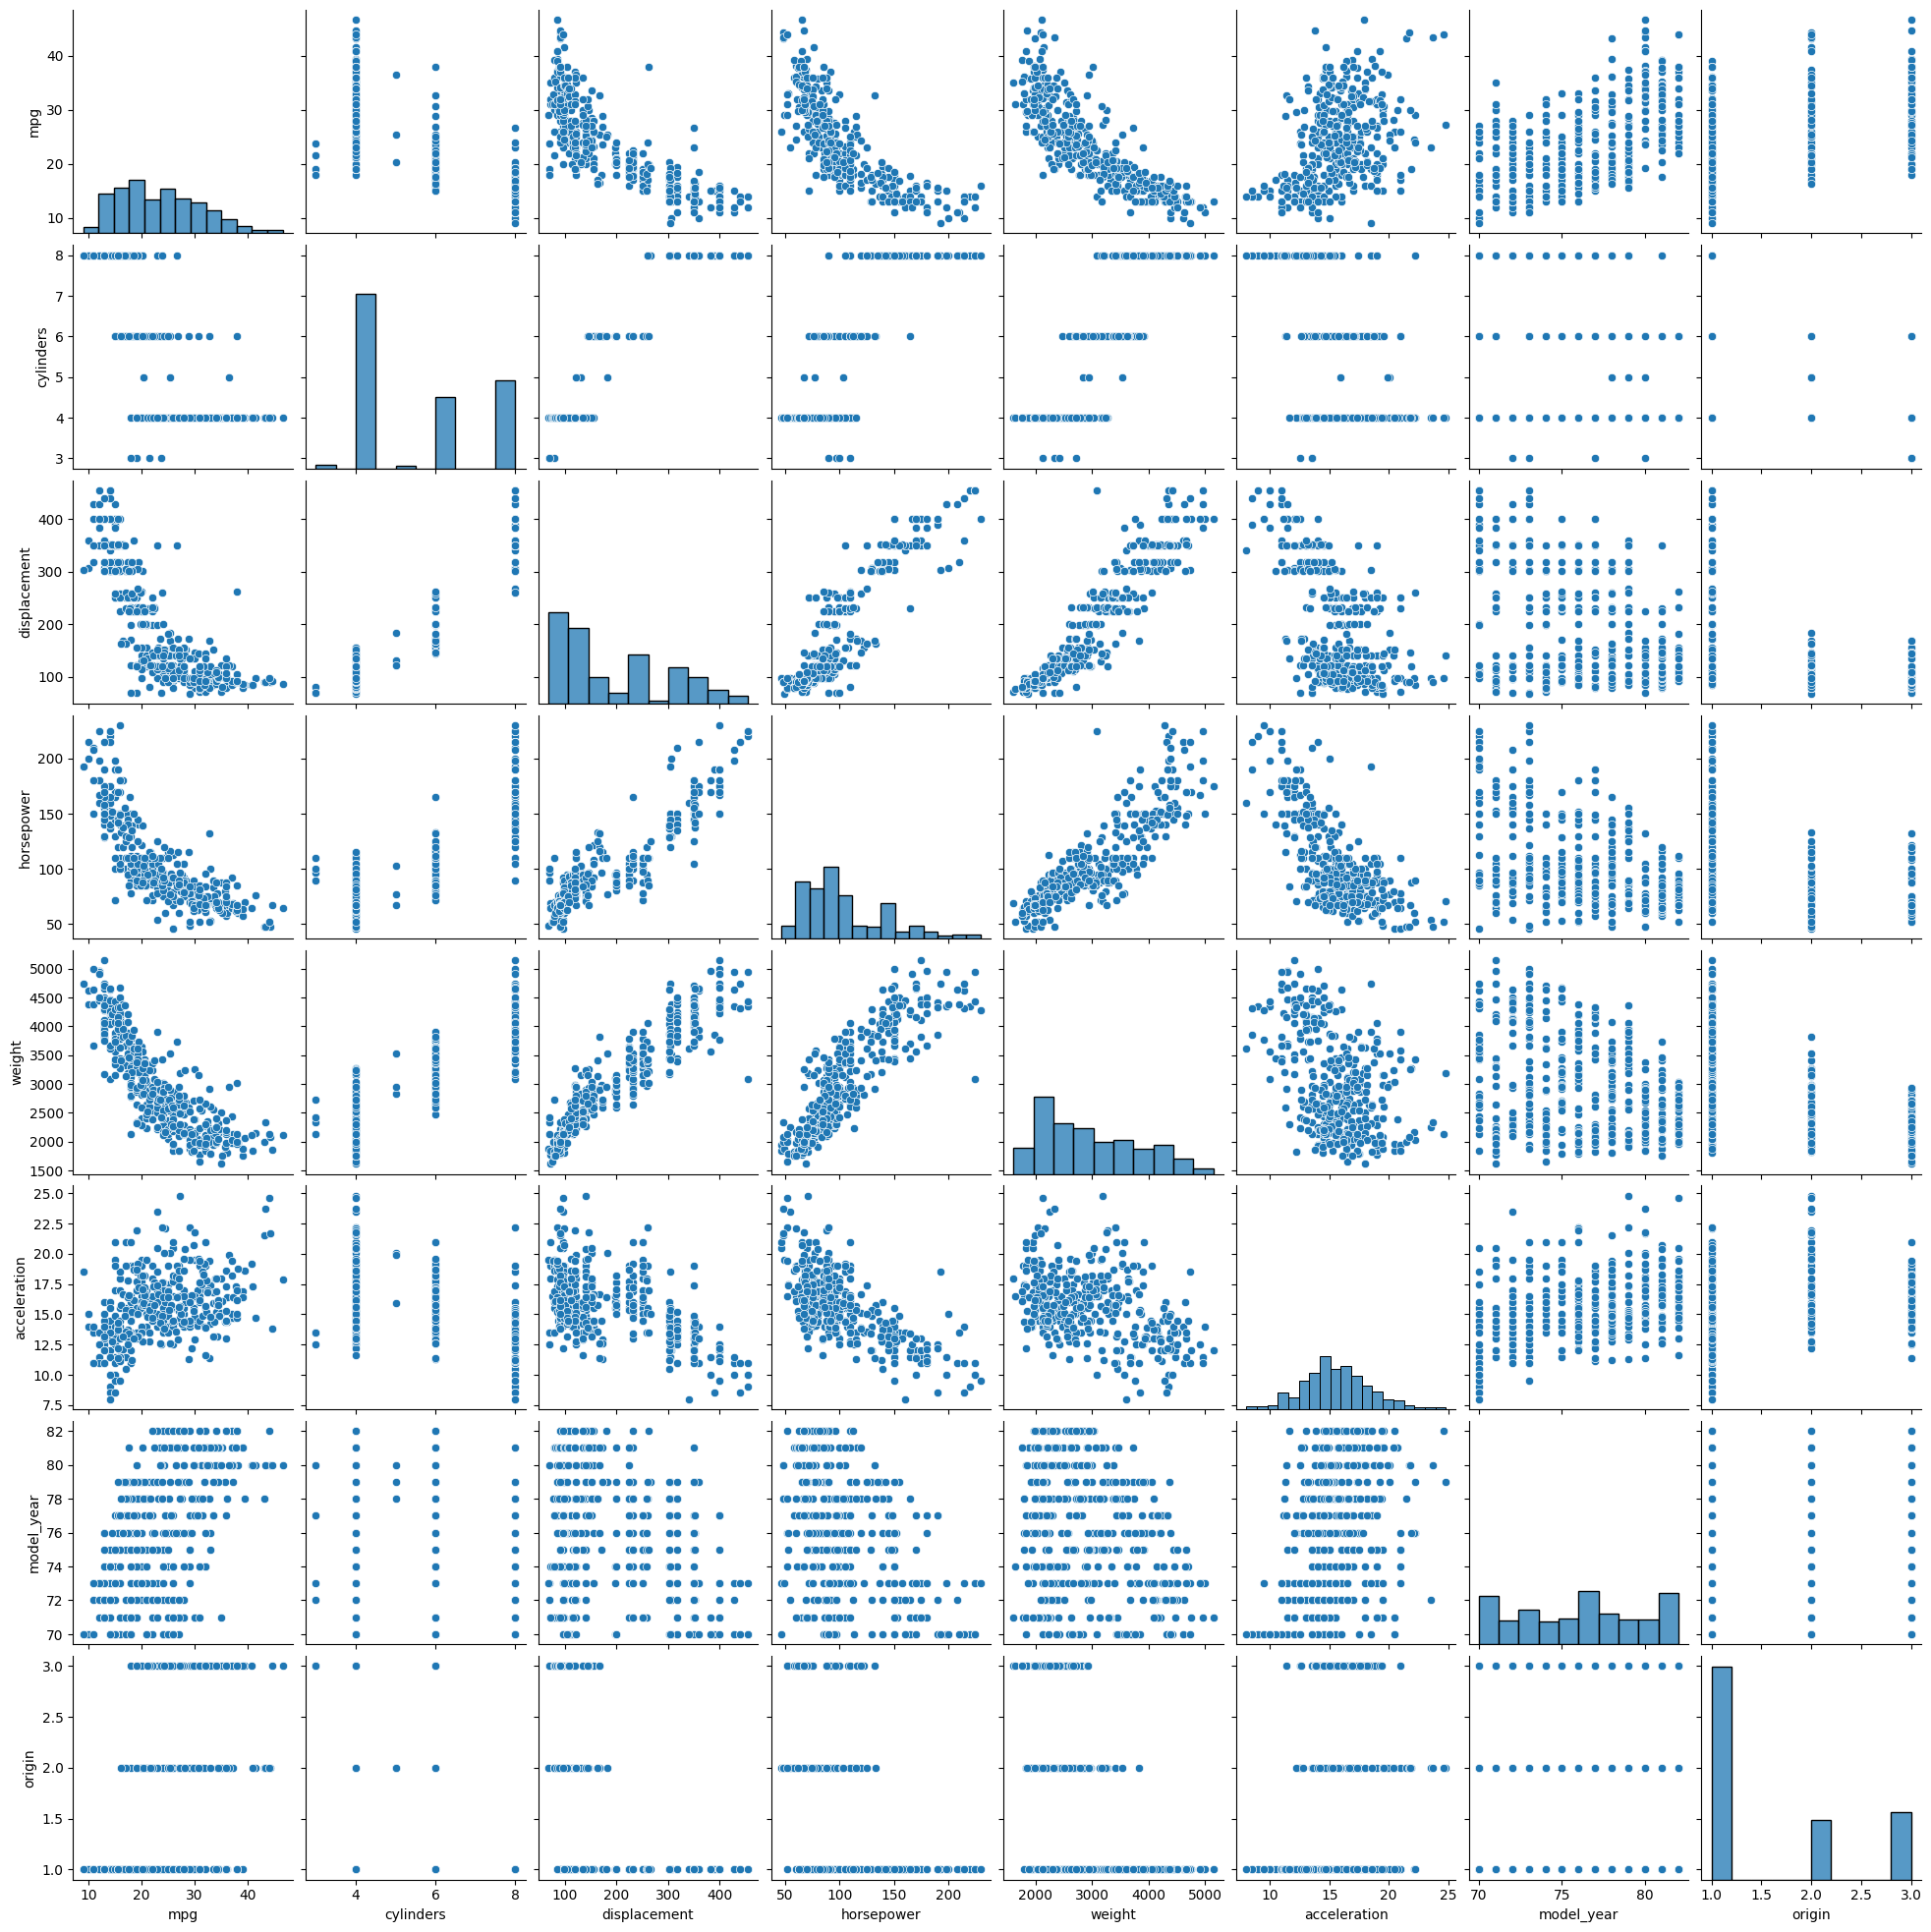

In [ ]:
sns.pairplot(df)

## Do you see any colinearity in the data?
* Can it cause any issue? How to deal with it?

<Axes: >

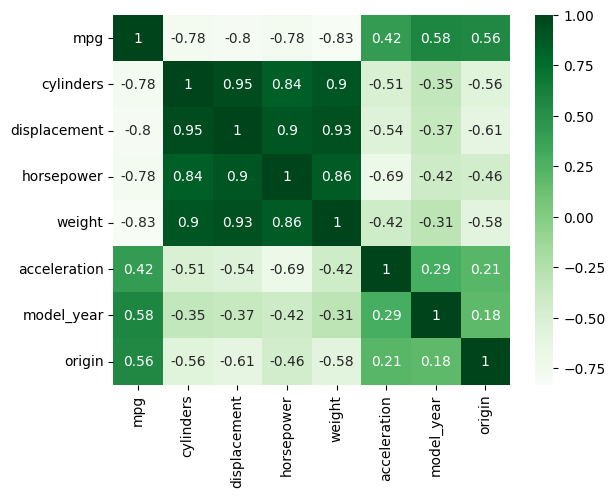

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap='Greens', annot=True)

## We can plot the categorical data using boxplots
* Beware that the data are about cars from 80s, we won't see many 6 or 8 cylinder cars nowadays

<Axes: xlabel='cylinders', ylabel='mpg'>

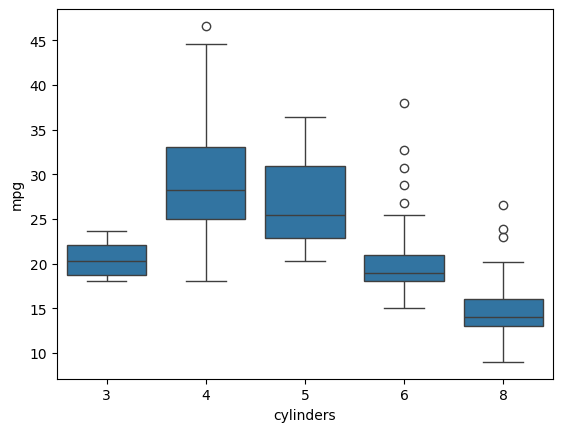

In [ ]:
sns.boxplot(data = df, x='cylinders', y='mpg')

<Axes: xlabel='origin', ylabel='mpg'>

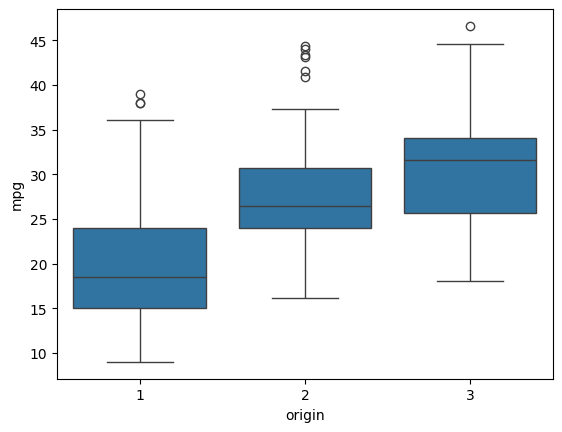

In [ ]:
sns.boxplot(data = df, x='origin', y='mpg')

## 💡 There is no info about the *origin* feature = detective work incoming 🙂

### What do you think that the origin means based on the printed data?
* And what car origin is your favourite? 🙂

In [ ]:
df.loc[df.origin == 1, 'car_name']

,car_name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino
...,...
392,chevrolet camaro
393,ford mustang gl
395,dodge rampage
396,ford ranger


In [ ]:
df.loc[df.origin == 2, 'car_name']

,car_name
19,volkswagen 1131 deluxe sedan
20,peugeot 504
21,audi 100 ls
22,saab 99e
23,bmw 2002
...,...
354,renault 18i
359,peugeot 505s turbo diesel
360,volvo diesel
375,volkswagen rabbit l


In [ ]:
df.loc[df.origin == 3, 'car_name']

,car_name
14,toyota corona mark ii
18,datsun pl510
29,datsun pl510
31,toyota corona
53,toyota corolla 1200
...,...
382,toyota corolla
383,honda civic
384,honda civic (auto)
385,datsun 310 gx


## Okay, now we have the basic understanding of the data we can start to try some models
* We need to deal with the NA values first, as is it just a few rows, we will drop the data

In [ ]:
df = df.loc[~df.horsepower.isna(), :].copy()

## 🏷️ Handling Categorical Features

Let's examine our categorical variables:

### Origin Feature 🌍
* Even though *origin* appears numerical (1, 2, 3)
* These numbers are actually codes representing:
  * 1 → American
  * 2 → European
  * 3 → Asian
* ⚠️ Why treat as categorical? Numbers don't represent order or magnitude!

### Car Name Feature 🚗
* Text data that needs encoding
* Contains brand/model information

❓ Key Question:
* Why is *origin* categorical despite being numerical? What's the catch?

### car_name is problematic beacause we have quite a few brands so one-hot encoding would add too many columns
* We will drop the feature

In [ ]:
df['car_name'].apply(lambda x: x.split(' ')[0]).value_counts()

,count
car_name,
ford,48
chevrolet,43
plymouth,31
dodge,28
amc,27
toyota,25
datsun,23
buick,17
pontiac,16


In [ ]:
df = df.drop('car_name', axis=1)

In [ ]:
df['origin'] = df['origin'].replace({1: 'USA', 2: 'EUR', 3: 'JAP'})

In [ ]:
df = pd.get_dummies(df, columns=['origin'], prefix=['origin_'])

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin__EUR,origin__JAP,origin__USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


## Split the data into input and output part

In [ ]:
X, y = df.drop('mpg', axis=1), df.mpg

In [ ]:
X.shape, y.shape

((392, 9), (392,))

## Do the train/test in ratio 80:20

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((313, 9), (79, 9), (313,), (79,))

## 🎯 Creating Baseline Model

We'll start with Linear Regression as our foundation:

### Linear Regression vs ANN 🤔
* Linear regression:
  * Simple mathematical formula
  * Clear coefficients for each feature
  * Direct feature importance interpretation

* Neural Network:
  * Complex layered structure
  * Hidden transformations
  * "Black box" nature

❓ Key Question:
* Which model provides better explainability - ANN or Linear Regression? Why?

![Meme01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_reg_01.jpg?raw=true)

## We will use just *horsepower* and *model_year* features because the high correlation values

In [ ]:
alg = LinearRegression()
alg.fit(X_train.loc[:, ['horsepower', 'model_year']], y_train)
y_pred = alg.predict(X_test.loc[:, ['horsepower', 'model_year']])

## 📊 Model Evaluation in Regression

### Common Regression Metrics 📏

1. Basic Metrics:
* MAE (Mean Absolute Error)
* RMSE (Root Mean Square Error)

2. Advanced Metrics:
* R² (R-squared)
* MAPE (Mean Absolute Percentage Error)
* sMAPE (Symmetric MAPE)

❓ Key Question:
* Can you write mathematical formulas for any of these metrics?
  * Think about:
    * Actual values (y)
    * Predicted values (ŷ)
    * Number of samples (n)

💡 Note: I've prepared evaluation functions to help you calculate all metrics easily!

In [ ]:
df_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
compute_metrics(df_pred)

,MAE,MSE,MAPE,SMAPE,R2
0,3.941482,23.74165,19.133313,19.846932,0.581278


# Now we can create our first deep learning model and compare it to the baseline
* The ANN model can use more features as it is designed for bigger datasets and multicolinearity is not so big issue as in the LR case
* We will start with a raw data
* The evaluation step is the same

![Meme02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_reg_04.jpg?raw=true)

## 🔎 Why do we use *linear* activation in the output layer?

# 📒 NOTE for Task 2: This is the benchmark model

In [ ]:
(X_train.shape[1],)

(9,)

In [ ]:
inp = keras.layers.Input(shape=(X_train.shape[1],))

hidden_1 = keras.layers.Dense(128, activation='relu')(inp)
hidden_2 = keras.layers.Dense(32, activation='relu')(hidden_1)

out = keras.layers.Dense(1, activation='linear')(hidden_2)

model = keras.Model(inp, out)

model.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.RMSprop(),
              metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

history = model.fit(X_train, y_train, validation_split=0.2, callbacks=[model_checkpoint_callback], batch_size=8, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 49808.1172 - mean_absolute_error: 114.0242 - mean_absolute_percentage_error: 603.4638 - val_loss: 138.9395 - val_mean_absolute_error: 10.1264 - val_mean_absolute_percentage_error: 53.8522
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1963.2115 - mean_absolute_error: 28.6218 - mean_absolute_percentage_error: 144.8455 - val_loss: 5058.0181 - val_mean_absolute_error: 70.0556 - val_mean_absolute_percentage_error: 339.1046
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2336.0662 - mean_absolute_error: 37.6566 - mean_absolute_percentage_error: 187.9205 - val_loss: 75.6994 - val_mean_absolute_error: 7.2387 - val_mean_absolute_percentage_error: 35.8676
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1301.0928 - mean_absolute_error: 26.4416 - mean_absolute_percentage_error: 131.0520 - val_loss: 142.3008 - val_mean_absolute_error: 10.3897 - val_mean_absolute_percentage_error: 41.7905
Epoch 5/100
32/32 

## 📈 Comparing Model Metrics

### Model Comparison 🔄
* Compare metrics between:
  * Linear Regression
  * Our Neural Network

❓ Key Questions:
* Is the model performing better? Why?
* What's the purpose of .ravel()?
  * Hint: Think about array dimensions!

💡 Note: .ravel() transforms multi-dimensional arrays into 1D arrays, which is often required for metric calculations.

In [ ]:
model.load_weights("best.weights.h5")

y_pred = model.predict(X_test).ravel()

df_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
compute_metrics(df_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


,MAE,MSE,MAPE,SMAPE,R2
0,3.473149,21.05248,15.570869,15.993674,0.628706


## It is very good practice to check the loss function values of train/validation data during the training and not only the metrics
* Do you see any issue with the val_loss?

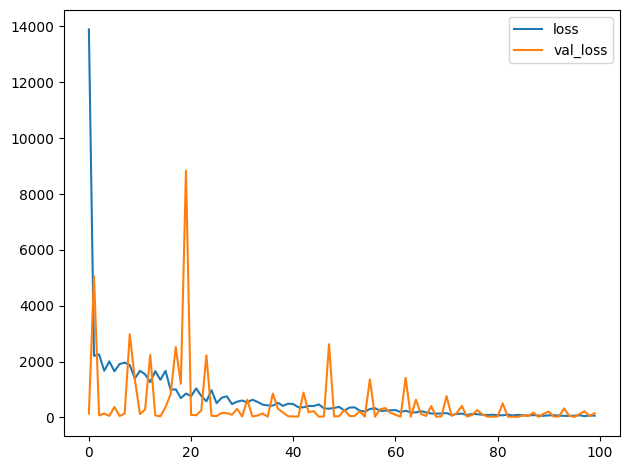

In [ ]:
show_history_loss(history)

## The loss function plot show clear instability of learning
* This is a big issue in the regression tasks and it is pretty common one
* It is caused by the features magnitude differences
* We can solve the matter with feature scaling (normalization)
* A https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization layer can be used for solving the matter

### Why is magnitude difference an issue?

* You can see that the gradient of the slope is orders of magnitude larger than the intercept.

![Grad01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_reg_noscale.png?raw=true)

* If we take a look at the one optimization step values change you can see that only the slope changed in value (we see a vertical line in the plot above, with no change in the intercept parameter).
    * That’s because the slope gradient is way bigger than the intercept gradient.
    * Gradient actually points in the direction of steepest ascent.
    * Gradient is the vector of all partial derivatives of the loss function with respect to all the model weights.
        * **Basically these values will tell you in which direction (+ or - delta) and how much you should change the individual weights values to lower the loss function value**
        * The amount we adjust our slope each iteration is controlled by a *learning rate* parameter
    
![Grad02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_reg_noscale_grad.png?raw=true)

### There are a few ways we can solve our problem above. The most common way is to simply scale your features before gradient descent.

![Grad03](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_reg_scale.png?raw=true)

* We can see that not the optimization process is not stuck and computed gradients in the individual steps points in the right direction.

![Grad04](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_reg_scale_grad.png?raw=true)


* **I recommend visiting https://www.tomasbeuzen.com/deep-learning-with-pytorch/chapters/chapter1_gradient-descent.html for more details about the topic**

## 🔄 Data Normalization

### Why Normalize? 🎯
* Neural networks are sensitive to input scales
* Features with different ranges can cause:
  * Slower convergence
  * Poor model performance
  * Training instability

### Process 🔧
1. Normalize features to similar ranges
2. Retrain the model
3. Compare results with previous version

❓ Key Questions:
* Will normalized data improve our model?
* How will the metrics change?

In [ ]:
norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(X_train.to_numpy())

## We can take a look at the mean and variance used in the normalization process for each feature

In [ ]:
print('Mean: ', np.array(norm_layer.variables[0]))
print('Variance: ', np.array(norm_layer.variables[1]))

Mean:  [5.4217253e+00 1.9218690e+02 1.0329713e+02 2.9654761e+03 1.5636742e+01
 7.6105431e+01 1.7891374e-01 1.9169329e-01 6.2939298e-01]
Variance:  [2.9147997e+00 1.0745592e+04 1.4390651e+03 7.1411250e+05 7.6496086e+00
 1.3800385e+01 1.4690362e-01 1.5494697e-01 2.3325746e-01]


In [ ]:
inp = keras.layers.Input(shape=(X_train.shape[1],))
norm = norm_layer(inp)
hidden_1 = keras.layers.Dense(128, activation='relu')(norm)
hidden_2 = keras.layers.Dense(32, activation='relu')(hidden_1)

out = keras.layers.Dense(1, activation='linear')(hidden_2)

model = keras.Model(inp, out)

model.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.RMSprop(),
              metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460 (21.33 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 19 (80.00 B)

## Train the model

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

history = model.fit(X_train, y_train, validation_split=0.2, callbacks=[model_checkpoint_callback], batch_size=8, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 524.9202 - mean_absolute_error: 21.5997 - mean_absolute_percentage_error: 93.3063 - val_loss: 413.1626 - val_mean_absolute_error: 19.1618 - val_mean_absolute_percentage_error: 79.6799
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 363.7620 - mean_absolute_error: 17.5882 - mean_absolute_percentage_error: 70.8957 - val_loss: 205.4879 - val_mean_absolute_error: 12.9135 - val_mean_absolute_percentage_error: 52.3126
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 148.1645 - mean_absolute_error: 10.5429 - mean_absolute_percentage_error: 42.1389 - val_loss: 55.3338 - val_mean_absolute_error: 5.7633 - val_mean_absolute_percentage_error: 24.3034
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 38.7834 - mean_absolute_error: 4.9675 - mean_absolute_percentage_error: 22.0731 - val_loss: 19.8388 - val_mean_absolute_error: 3.2405 - val_mean_absolute_percentage_error: 14.0091
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━

In [ ]:
model.load_weights("best.weights.h5")

y_pred = model.predict(X_test).ravel()

df_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
compute_metrics(df_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


,MAE,MSE,MAPE,SMAPE,R2
0,2.30898,10.081556,10.283491,10.287546,0.822196


## 👀 Analyzing the Impact of Normalization

### Before vs After Comparison 📊
* Training behavior
* Convergence speed
* Final metrics

### Why Normalization Matters 🎯
* Similar scales → Stable gradients
* Benefits:
  * ⚡ Faster convergence
  * 📈 Higher learning rates possible
  * 🎯 Better numerical stability

❓ Key Question:
* Do you notice any differences in model performance after normalization?

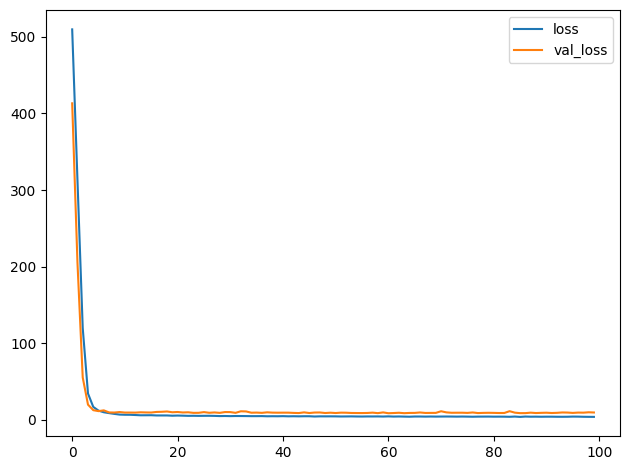

In [ ]:
show_history_loss(history)

## We can transform the output as well
* There are multiple scaling options
    * MinMax, Std. scale, Log, BoxCox, ...
    
### We will test *MinMaxScaler* into (-1;1) range

In [ ]:
scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = scaler.fit_transform(np.array(y_train).reshape((-1, 1))).ravel()
y_test_scaled = scaler.transform(np.array(y_test).reshape((-1, 1))).ravel()

In [ ]:
y_train_scaled[:10]

array([ 0.32978723, -0.04255319, -0.09574468, -0.44680851, -0.73404255,
       -0.12234043, -0.68085106, -0.30851064, -0.36170213, -0.38829787])

## ⚠️ Output Activation Function Warning

### The Activation Range Problem 🎯
* Sigmoid → [0,1] range only
* Can't produce negative values
* Real data may need wider range

❓ Key Question:
* What happens when activation function range doesn't match our target variable range?

💡 Remember: Always match your output activation to your target variable range!
* Linear → unbounded values
* ReLU → positive values
* Sigmoid → [0,1]
* Tanh → [-1,1]

### Anti-Pattern Example ☣️
* Using sigmoid for unbounded regression
* Model will be limited to positive values
* Can't predict full range of target variable

In [ ]:
inp = keras.layers.Input(shape=(X_train.shape[1],))
norm = norm_layer(inp)
hidden_1 = keras.layers.Dense(128, activation='relu')(norm)
hidden_2 = keras.layers.Dense(32, activation='relu')(hidden_1)

out = keras.layers.Dense(1, activation='sigmoid')(hidden_2)

model = keras.Model(inp, out)

model.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.RMSprop(),
              metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460 (21.33 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 19 (80.00 B)

## Train the model

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

history = model.fit(X_train, y_train_scaled, validation_split=0.2, callbacks=[model_checkpoint_callback], batch_size=8, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4211 - mean_absolute_error: 0.5375 - mean_absolute_percentage_error: 288.1225 - val_loss: 0.2210 - val_mean_absolute_error: 0.4003 - val_mean_absolute_percentage_error: 155.8111
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2338 - mean_absolute_error: 0.4019 - mean_absolute_percentage_error: 123.2732 - val_loss: 0.1942 - val_mean_absolute_error: 0.3702 - val_mean_absolute_percentage_error: 137.7168
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2205 - mean_absolute_error: 0.3866 - mean_absolute_percentage_error: 120.4839 - val_loss: 0.1951 - val_mean_absolute_error: 0.3730 - val_mean_absolute_percentage_error: 178.6506
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1904 - mean_absolute_error: 0.3513 - mean_absolute_percentage_error: 109.0935 - val_loss: 0.1882 - val_mean_absolute_error: 0.3606 - val_mean_absolute_percentage_error: 133.6752
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

In [ ]:
model.load_weights("best.weights.h5")

y_pred = model.predict(X_test).ravel()

df_pred = pd.DataFrame({'y_true': y_test_scaled, 'y_pred': y_pred})
compute_metrics(df_pred)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


,MAE,MSE,MAPE,SMAPE,R2
0,0.394992,0.218648,90.078065,170.379101,-0.362935


## Now we can transfer the data back

In [ ]:
y_pred = scaler.inverse_transform(y_pred.reshape((-1, 1))).ravel()
y_pred[:10]

array([27.8     , 27.800007, 27.8     , 27.8     , 27.804401, 27.8166  ,
       27.892292, 32.646626, 27.8     , 31.068954], dtype=float32)

In [ ]:
df_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
compute_metrics(df_pred)

,MAE,MSE,MAPE,SMAPE,R2
0,7.425853,77.278789,43.601941,32.375801,-0.362935


## 📊 Analyzing Predictions vs Reality

### Spotting the Problem 🔍
* Predictions limited to [0,1] range
* Actual values much wider range
* Clear mismatch visible in plot

### Ideal Plot Should Show 📈
* Points following diagonal line
* No range restrictions
* Even distribution above/below line

❓ Key Questions:
* Can you identify the sigmoid limitation in the plot?

💡 Remember: A good regression plot should show points clustered along y=x line without artificial boundaries!

<Axes: xlabel='mpg'>

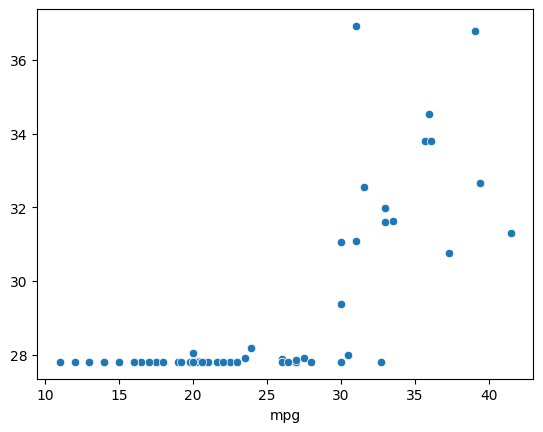

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)

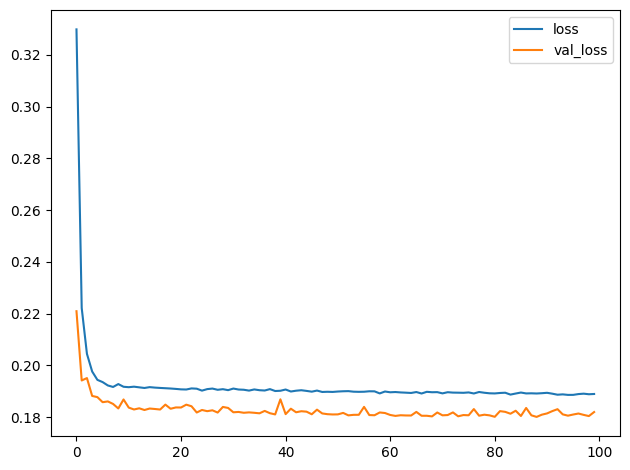

In [ ]:
show_history_loss(history)

# ✅ Now we will try to fix the issue and replace sigmoid function with the correct one
* What function can we use? Why?

In [ ]:
inp = keras.layers.Input(shape=(X_train.shape[1],))
norm = norm_layer(inp)
hidden_1 = keras.layers.Dense(128, activation='relu')(norm)
hidden_2 = keras.layers.Dense(32, activation='relu')(hidden_1)

out = keras.layers.Dense(1, activation='tanh')(hidden_2)

model = keras.Model(inp, out)

model.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.RMSprop(),
              metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460 (21.33 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 19 (80.00 B)

## Train the model

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

history = model.fit(X_train, y_train_scaled, validation_split=0.2, callbacks=[model_checkpoint_callback], batch_size=8, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - mean_absolute_error: 0.1952 - mean_absolute_percentage_error: 118.6164 - val_loss: 0.0278 - val_mean_absolute_error: 0.1243 - val_mean_absolute_percentage_error: 78.9522
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0295 - mean_absolute_error: 0.1195 - mean_absolute_percentage_error: 95.4746 - val_loss: 0.0259 - val_mean_absolute_error: 0.1232 - val_mean_absolute_percentage_error: 73.8792
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - mean_absolute_error: 0.0972 - mean_absolute_percentage_error: 77.9520 - val_loss: 0.0383 - val_mean_absolute_error: 0.1601 - val_mean_absolute_percentage_error: 106.5907
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - mean_absolute_error: 0.0878 - mean_absolute_percentage_error: 77.4650 - val_loss: 0.0367 - val_mean_absolute_error: 0.1492 - val_mean_absolute_percentage_error: 103.8252
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/ste

In [ ]:
model.load_weights("best.weights.h5")

y_pred = model.predict(X_test).ravel()

df_pred = pd.DataFrame({'y_true': y_test_scaled, 'y_pred': y_pred})
compute_metrics(df_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


,MAE,MSE,MAPE,SMAPE,R2
0,0.123099,0.029675,51.937092,47.937167,0.815022


## Now we can transfer the data back

In [ ]:
y_pred = scaler.inverse_transform(y_pred.reshape((-1, 1))).ravel()
y_pred[:10]

array([18.539694, 19.191067, 13.513393, 11.297284, 24.544014, 24.545244,
       25.743195, 32.67001 , 16.6086  , 31.305431], dtype=float32)

In [ ]:
df_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred})
compute_metrics(df_pred)

,MAE,MSE,MAPE,SMAPE,R2
0,2.314258,10.488285,10.566529,10.232736,0.815022


# Plot of the y_test vs. y_pred
* Is it better?

<Axes: xlabel='mpg'>

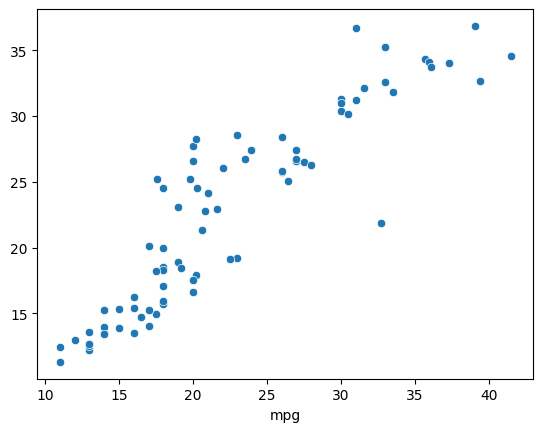

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)

## The convergence was quite fast
* We can see that there is an issue with the val_loss stability as the changes are very low now

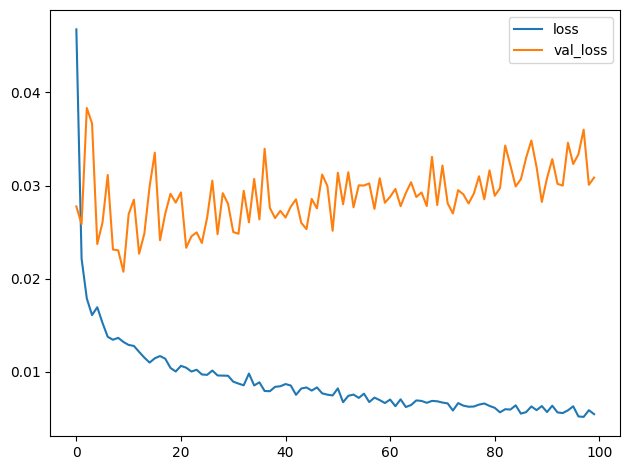

In [ ]:
show_history_loss(history)

## ✅  Tasks for the lecture (2p)

1) Try to use [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html) for the output values in a similar manner
as the MinMaxScaler - **(1p)**

    - When do we use it? Why?
    
    - If you wanted to guess if it helps, what do you think?
        * Plot histogram of the output (*mpg*), you can make an educated guess based on it 🙂
    
2) Try to design your own network and beat the **benchmark** network used in the lecture - **(1p)**

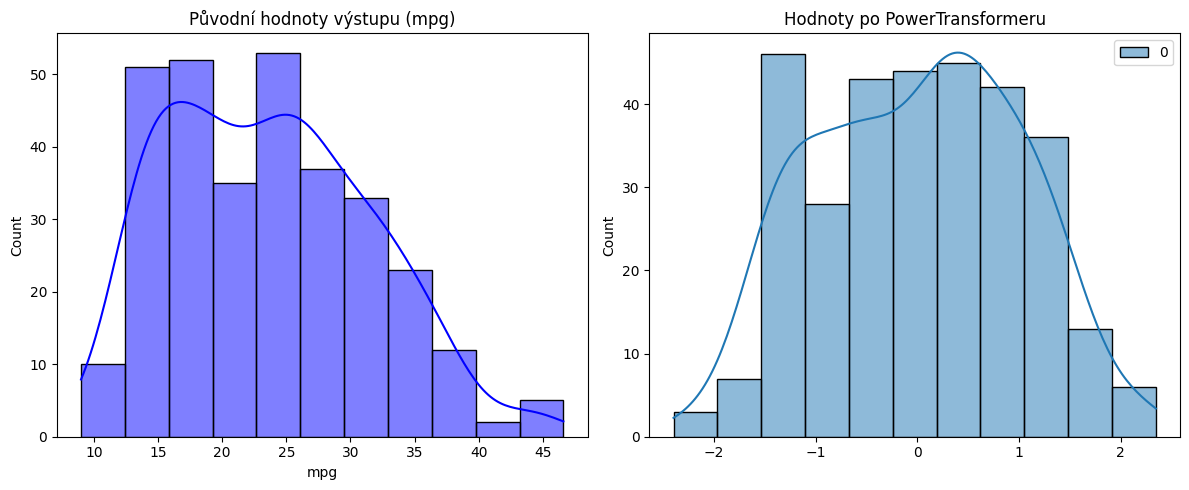

In [ ]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1, 1))

y_test_pt = pt.transform(y_test.values.reshape(-1, 1))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(y_train, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Původní hodnoty výstupu (mpg)')

sns.histplot(y_train_pt, kde=True, ax=ax[1], color='green')
ax[1].set_title('Hodnoty po PowerTransformeru')

plt.tight_layout()
plt.show()

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.7973 - mean_absolute_error: 0.7157 - mean_absolute_percentage_error: 101.4831 - val_loss: 0.1762 - val_mean_absolute_error: 0.3364 - val_mean_absolute_percentage_error: 166.0033
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1667 - mean_absolute_error: 0.3196 - mean_absolute_percentage_error: 65.5981 - val_loss: 0.1609 - val_mean_absolute_error: 0.3283 - val_mean_absolute_percentage_error: 142.0409
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1229 - mean_absolute_error: 0.2771 - mean_absolute_percentage_error: 71.8883 - val_loss: 0.1396 - val_mean_absolute_error: 0.3011 - val_mean_absolute_percentage_error: 125.2831
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1098 - mean_absolute_error: 0.2535 - mean_absolute_percentage_error: 57.8887 - val_loss: 0.1341 - val_mean_absolute_error: 0.2930 - val_mean_absolute_percentage_error: 112.3311
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1

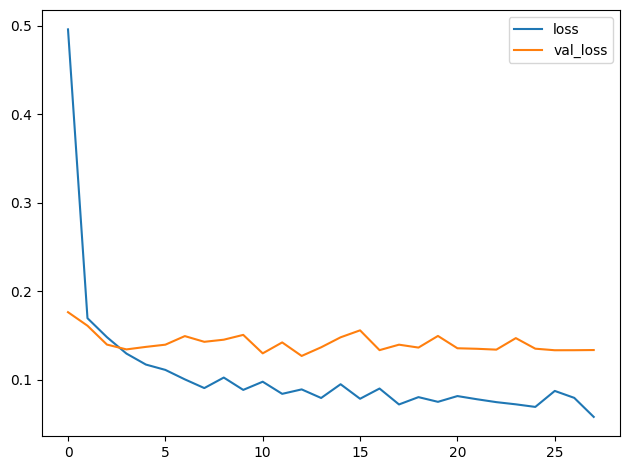

In [ ]:
inp = keras.layers.Input(shape=(X_train.shape[1],))
norm = norm_layer(inp)

# Větší hloubka sítě a vrstvy Dropout
hidden_1 = keras.layers.Dense(256, activation='relu')(norm)
dropout_1 = keras.layers.Dropout(0.2)(hidden_1)

hidden_2 = keras.layers.Dense(128, activation='relu')(dropout_1)
dropout_2 = keras.layers.Dropout(0.2)(hidden_2)

hidden_3 = keras.layers.Dense(64, activation='relu')(dropout_2)

# Výstupní vrstva musí mít lineární aktivaci, protože pt.fit_transform generuje i záporná čísla!
out = keras.layers.Dense(1, activation='linear')(hidden_3)

custom_model = keras.Model(inp, out)

custom_model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()]
)

# Pokud se val_loss nezlepší po dobu 15 epoch, zastaví učení a vrátí nejlepší váhy
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_custom = custom_model.fit(
    X_train,
    y_train_pt,
    validation_split=0.2,
    batch_size=16,
    epochs=150,
    callbacks=[early_stopping],
    verbose=1
)

show_history_loss(history_custom)

In [ ]:
y_pred_scaled = custom_model.predict(X_test)

y_pred = pt.inverse_transform(y_pred_scaled)

df_metrics = compute_metrics_raw(y_test, y_pred.flatten())
display(df_metrics)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


,MAE,MSE,MAPE,SMAPE,R2
0,2.26581,10.231497,10.009366,9.782627,0.819551
